In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [15]:
df = pd.read_csv("loan_approval_data.csv")
df.head()
df.info()
df.isnull().sum()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [16]:

##Handle Missing Values

categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns








In [17]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df[numerical_cols].head()





,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0


In [18]:

cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])
df[categorical_cols].head()




,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes


In [19]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

Text(0.5, 1.0, 'Is Loan Approved or not?')

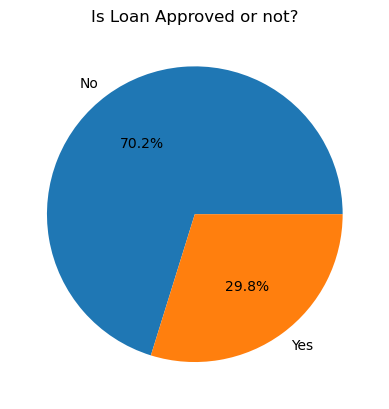

In [20]:
#EDA - Exploratory data analysis
#how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count , labels = ["No" , "Yes"] , autopct = "%1.1f%%")
plt.title("Is Loan Approved or not?")






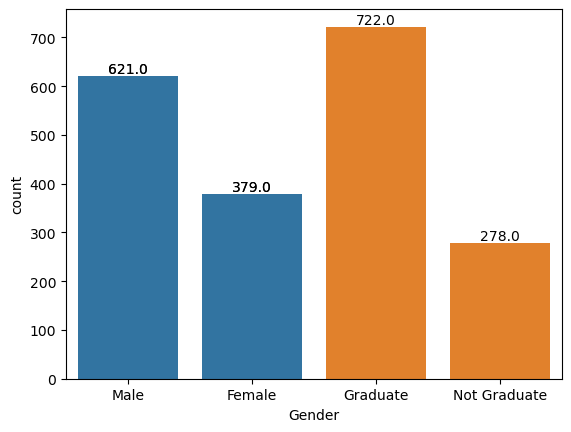

In [21]:
#analyze Categories

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
for container in ax.containers:
    ax.bar_label(container , fmt="%.1f")


edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
for container in ax.containers:
    ax.bar_label(container , fmt="%.1f")








 


<Axes: xlabel='Applicant_Income', ylabel='Count'>

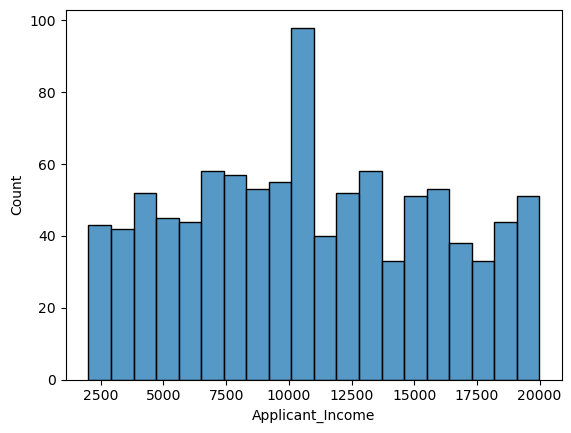

In [22]:
#analyze income 
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

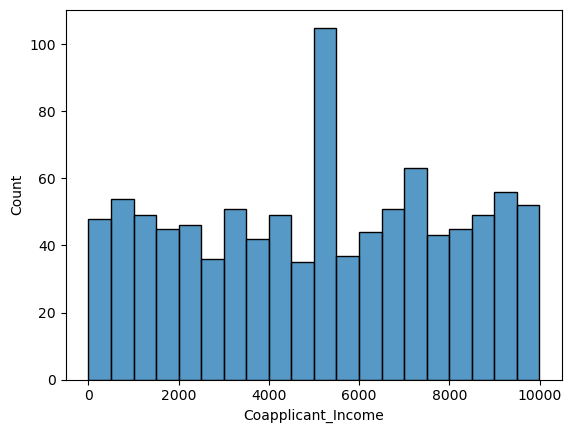

In [23]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

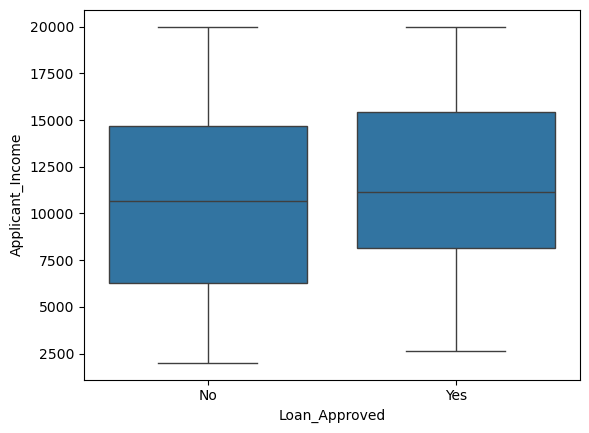

In [24]:
#Outliers - Box plot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

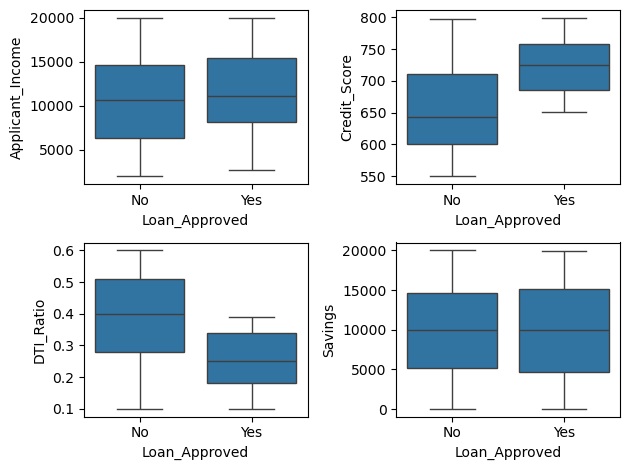

In [25]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0] , data = df , x = "Loan_Approved" , y = "Applicant_Income")
sns.boxplot(ax = axes[0,1] , data = df , x = "Loan_Approved" , y = "Credit_Score")
sns.boxplot(ax = axes[1,0] , data = df , x = "Loan_Approved" , y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1] , data = df , x = "Loan_Approved" , y = "Savings")

fig.tight_layout()

In [26]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


<Axes: xlabel='Credit_Score', ylabel='Count'>

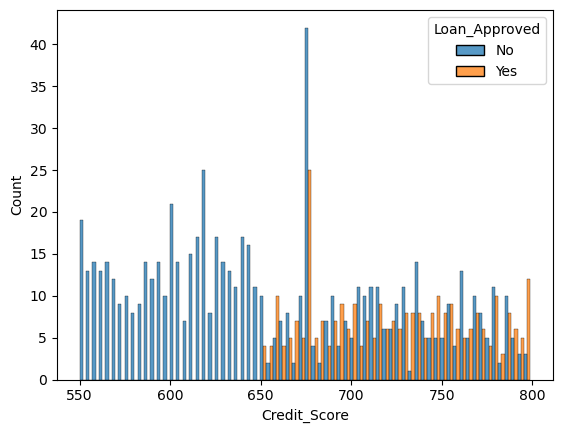

In [27]:
#Credit Score with Loan Approval 
sns.histplot(
    data = df , 
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 70,
    multiple = "dodge"
)

<Axes: xlabel='Savings', ylabel='Count'>

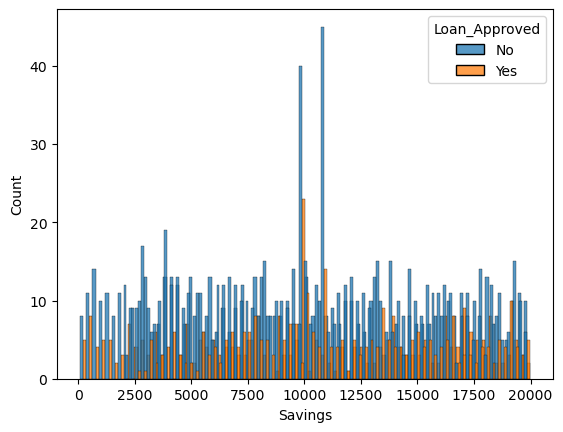

In [28]:
#Savings with loan Approval
sns.histplot(
    data = df , 
    x = "Savings",
    hue = "Loan_Approved",
    bins = 70,
    multiple = "dodge"
)


#Applicant income with loan Approval
sns.histplot(
    data = df , 
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins = 70,
    multiple = "dodge"
)




In [29]:
#Remove Applicant ID
df = df.drop("Applicant_ID" , axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [30]:
#Encoding 
#Label Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df[ "Loan_Approved" ] = le.fit_transform(df[ "Loan_Approved"])










In [31]:
# One Hot Encoding
cols = [ "Employment_Status" , "Marital_Status" ,"Loan_Purpose" , "Property_Area" , "Education_Level", "Gender" , "Employer_Category" ,"Loan_Approved"   ]
ohe = OneHotEncoder(drop = "first" , handle_unknown = "ignore" , sparse_output = False)
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(cols) , index = df.index)
df = pd.concat([df.drop(columns = cols) , encoded_df], axis = 1)



In [32]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Employment_Status_Salaried       1000 non-null   float64
 12  Employment_Status_Sel

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Approved_1
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,...,0.178000,0.189000,0.517000,0.278000,0.621000,0.202000,0.144000,0.422000,0.097000,0.298000
std,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,...,0.382704,0.391705,0.499961,0.448238,0.485381,0.401693,0.351265,0.494126,0.296106,0.457608
min,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,...,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

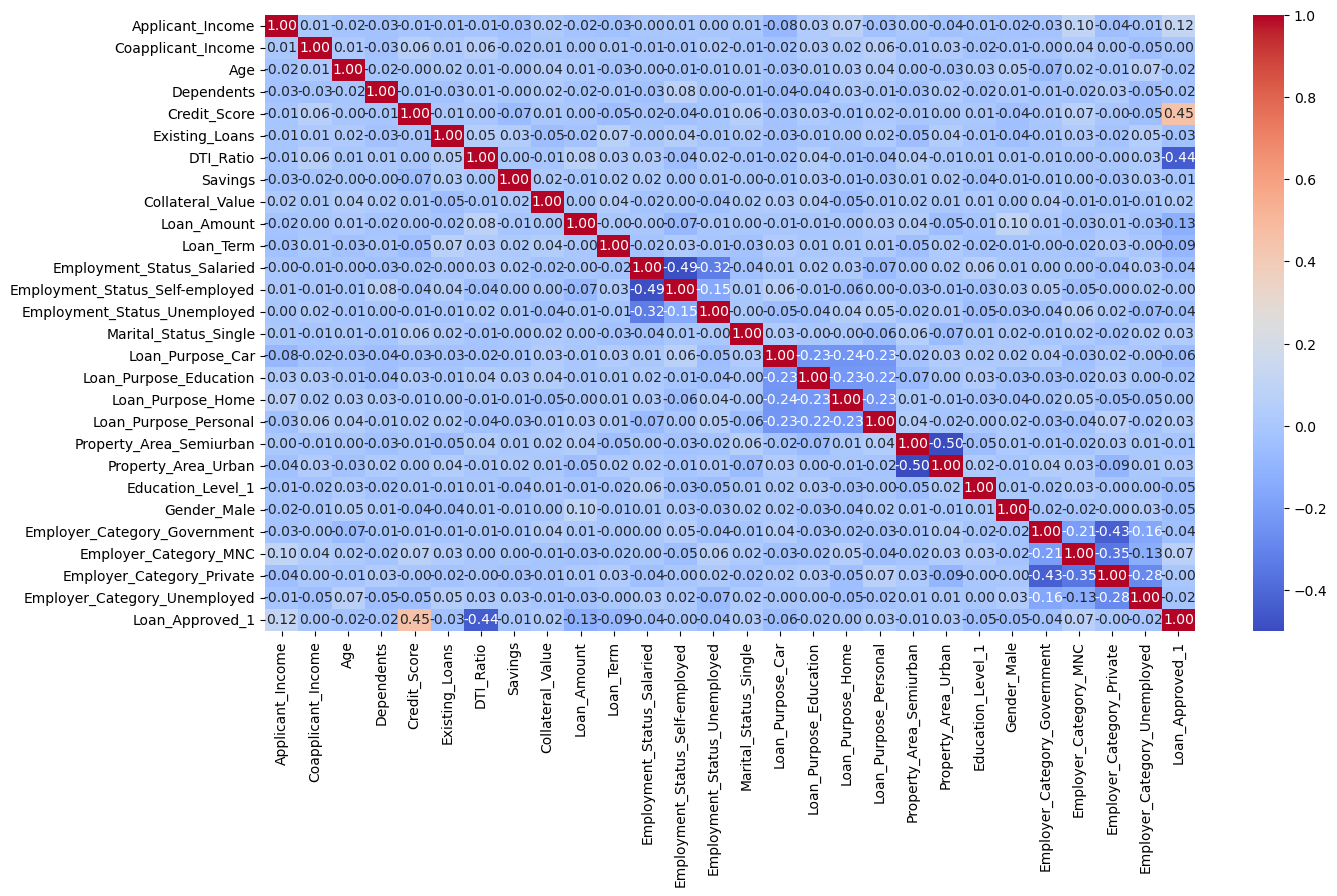

In [33]:
num_cols = df.select_dtypes(include = "number")
corr_matrix =  num_cols.corr()

plt.figure(figsize =(15,8))

sns.heatmap(
    corr_matrix , 
    annot = True , 
    fmt = ".2f",
    cmap = "coolwarm",
    
)

#Here strongest values less -  linear model not perform well

num_cols.corr()["Loan_Approved_1"].sort_values(ascending = False)


In [34]:
#Train test split + Feature Scaling
X = df.drop("Loan_Approved_1"  , axis = 1)
y = df['Loan_Approved_1']





In [35]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.2 , random_state = 42)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Train and Evaluate Models



In [37]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)
y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression")
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 score:" , f1_score(y_test , y_pred))
print("Accuarcy:" , accuracy_score(y_test , y_pred))
print("CM:" , confusion_matrix(y_test , y_pred))

 

Logistic Regression
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 score: 0.7768595041322314
Accuarcy: 0.865
CM: [[126  13]
 [ 14  47]]


In [38]:
#KNN 
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 7)
knn_model.fit(X_train_scaled , y_train)
y_pred = knn_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression")
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 score:" , f1_score(y_test , y_pred))
print("Accuarcy:" , accuracy_score(y_test , y_pred))
print("CM:" , confusion_matrix(y_test , y_pred))


Logistic Regression
Precision: 0.6086956521739131
Recall: 0.45901639344262296
F1 score: 0.5233644859813084
Accuarcy: 0.745
CM: [[121  18]
 [ 33  28]]


In [39]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)
y_pred = nb_model.predict(X_test_scaled)

#Evaluation
print("Naive Bayes")
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 score:" , f1_score(y_test , y_pred))
print("Accuarcy:" , accuracy_score(y_test , y_pred))
print("CM:" , confusion_matrix(y_test , y_pred))

#Naive Bayes clearly win 

Naive Bayes
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 score: 0.7692307692307693
Accuarcy: 0.865
CM: [[128  11]
 [ 16  45]]


Feature Engineering

In [40]:
#Add or Transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])
X = df.drop(columns = ["Loan_Approved_1" , "Credit_Score" , "DTI_Ratio"])
y = df["Loan_Approved_1"]

#Train test split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.2 , random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.head()







,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Employment_Status_Salaried,...,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


In [41]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)
y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression")
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 score:" , f1_score(y_test , y_pred))
print("Accuarcy:" , accuracy_score(y_test , y_pred))
print("CM:" , confusion_matrix(y_test , y_pred))

#According to balance of precision and Recall logistic regression model is best

 

Logistic Regression
Precision: 0.7903225806451613
Recall: 0.8032786885245902
F1 score: 0.7967479674796748
Accuarcy: 0.875
CM: [[126  13]
 [ 12  49]]


In [42]:
#KNN 
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 9)
knn_model.fit(X_train_scaled , y_train)
y_pred = knn_model.predict(X_test_scaled)

#Evaluation
print("Logistic Regression")
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 score:" , f1_score(y_test , y_pred))
print("Accuarcy:" , accuracy_score(y_test , y_pred))
print("CM:" , confusion_matrix(y_test , y_pred))


Logistic Regression
Precision: 0.6666666666666666
Recall: 0.4918032786885246
F1 score: 0.5660377358490566
Accuarcy: 0.77
CM: [[124  15]
 [ 31  30]]


In [43]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)
y_pred = nb_model.predict(X_test_scaled)

#Evaluation
print("Naive Bayes")
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 score:" , f1_score(y_test , y_pred))
print("Accuarcy:" , accuracy_score(y_test , y_pred))
print("CM:" , confusion_matrix(y_test , y_pred))

#According to precision this model is best 
#Naive Bayes model is best for loan dataset


Naive Bayes
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 score: 0.7768595041322314
Accuarcy: 0.865
CM: [[126  13]
 [ 14  47]]
